<a href="https://colab.research.google.com/github/chintugani269-boop/Employee-Attrition-Prediction/blob/main/Employee_Attrition_Prediction_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Employee Attrition Prediction***
***& Workforce Analysis***

***Machine Learning Project***

***Python | Pandas | Seaborn | Scikit-learn***

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [47]:
df = pd.read_csv(
    "WA_Fn-UseC_-HR-Employee-Attrition.csv"
)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [48]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1470
Columns: 35


In [49]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [50]:
df.tail(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1460,29,No,Travel_Rarely,468,Research & Development,28,4,Medical,1,2054,...,2,80,0,5,3,1,5,4,0,4
1461,50,Yes,Travel_Rarely,410,Sales,28,3,Marketing,1,2055,...,2,80,1,20,3,3,3,2,2,0
1462,39,No,Travel_Rarely,722,Sales,24,1,Marketing,1,2056,...,1,80,1,21,2,2,20,9,9,6
1463,31,No,Non-Travel,325,Research & Development,5,3,Medical,1,2057,...,2,80,0,10,2,3,9,4,1,7
1464,26,No,Travel_Rarely,1167,Sales,5,3,Other,1,2060,...,4,80,0,5,2,3,4,2,0,0
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [52]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [53]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [54]:
missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_percentage.sort_values(
    ascending=False
)

,0
Age,0.0
Attrition,0.0
BusinessTravel,0.0
DailyRate,0.0
Department,0.0
DistanceFromHome,0.0
Education,0.0
EducationField,0.0
EmployeeCount,0.0
EmployeeNumber,0.0


In [55]:
print(
    "Duplicate Rows:",
    df.duplicated().sum()
)

Duplicate Rows: 0


In [56]:
df = df.drop_duplicates()

print("Dataset Shape:", df.shape)

Dataset Shape: (1470, 35)


In [57]:
for column in df.columns:
    print(
        column,
        ":",
        df[column].nunique()
    )

Age : 43
Attrition : 2
BusinessTravel : 3
DailyRate : 886
Department : 3
DistanceFromHome : 29
Education : 5
EducationField : 6
EmployeeCount : 1
EmployeeNumber : 1470
EnvironmentSatisfaction : 4
Gender : 2
HourlyRate : 71
JobInvolvement : 4
JobLevel : 5
JobRole : 9
JobSatisfaction : 4
MaritalStatus : 3
MonthlyIncome : 1349
MonthlyRate : 1427
NumCompaniesWorked : 10
Over18 : 1
OverTime : 2
PercentSalaryHike : 15
PerformanceRating : 2
RelationshipSatisfaction : 4
StandardHours : 1
StockOptionLevel : 4
TotalWorkingYears : 40
TrainingTimesLastYear : 7
WorkLifeBalance : 4
YearsAtCompany : 37
YearsInCurrentRole : 19
YearsSinceLastPromotion : 16
YearsWithCurrManager : 18


In [58]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

print(numeric_columns)

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


In [59]:
categorical_columns = df.select_dtypes(
    include='object'
).columns

print(categorical_columns)

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


In [60]:
target = "Attrition"

df[target].value_counts()

,count
Attrition,
No,1233
Yes,237


In [61]:
df[target].value_counts(
    normalize=True
) * 100

,proportion
Attrition,
No,83.877551
Yes,16.122449


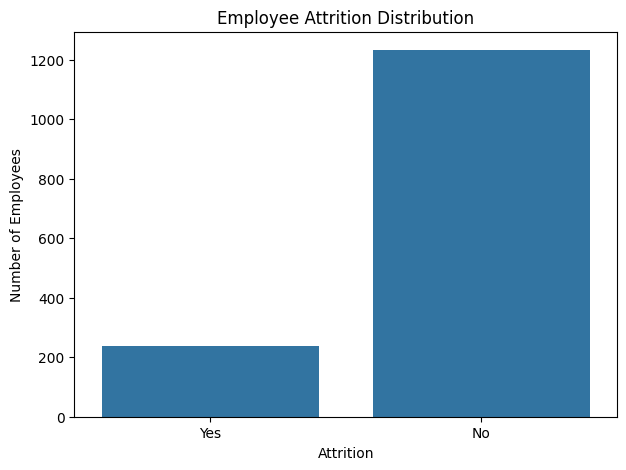

In [62]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='Attrition'
)

plt.title(
    'Employee Attrition Distribution'
)

plt.xlabel('Attrition')
plt.ylabel('Number of Employees')

plt.show()

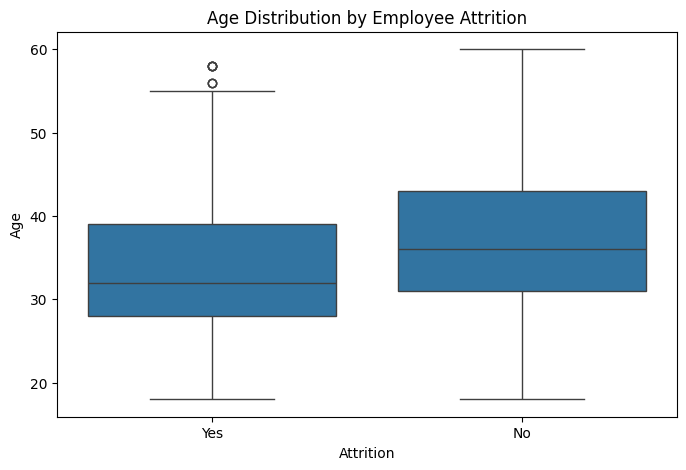

In [63]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Attrition',
    y='Age'
)

plt.title(
    'Age Distribution by Employee Attrition'
)

plt.show()

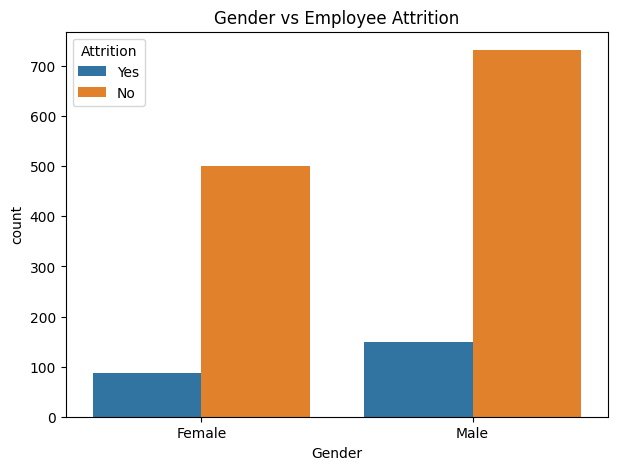

In [64]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='Gender',
    hue='Attrition'
)

plt.title(
    'Gender vs Employee Attrition'
)

plt.show()

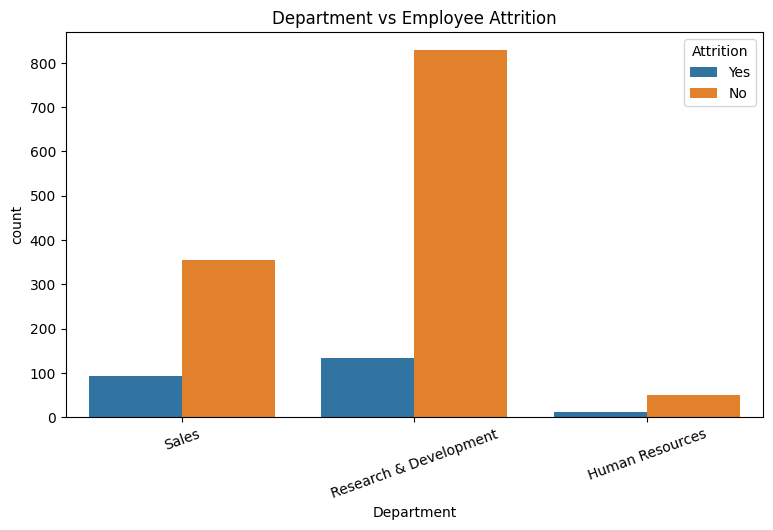

In [65]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x='Department',
    hue='Attrition'
)

plt.title(
    'Department vs Employee Attrition'
)

plt.xticks(rotation=20)

plt.show()

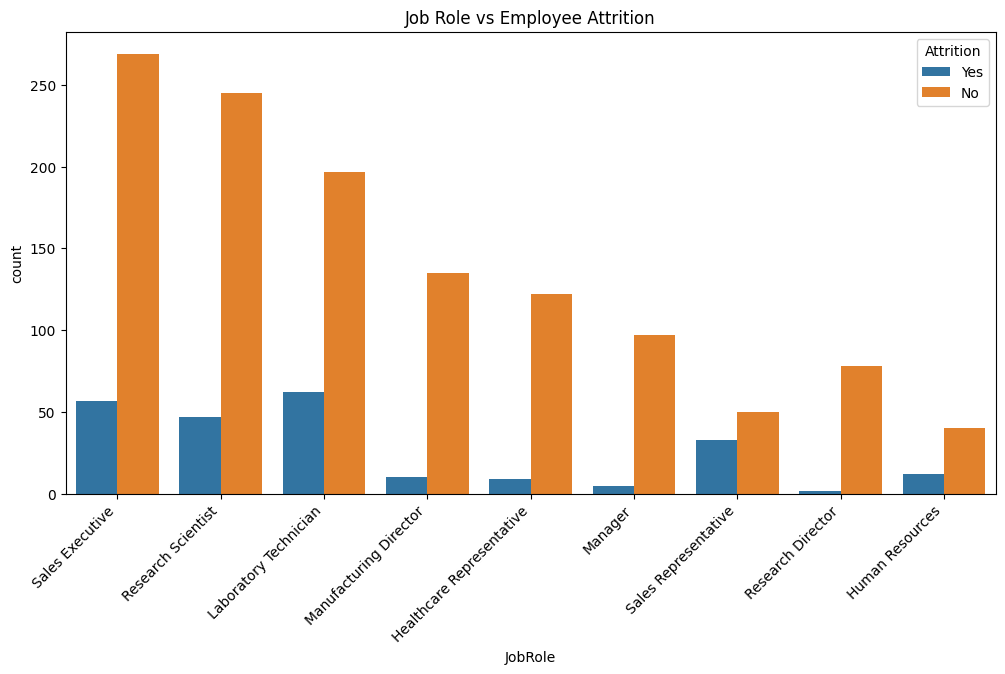

In [66]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='JobRole',
    hue='Attrition'
)

plt.title(
    'Job Role vs Employee Attrition'
)

plt.xticks(
    rotation=45,
    ha='right'
)

plt.show()

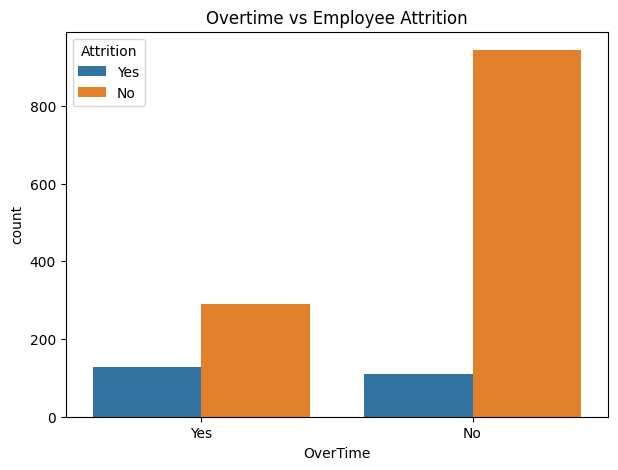

In [67]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='OverTime',
    hue='Attrition'
)

plt.title(
    'Overtime vs Employee Attrition'
)

plt.show()

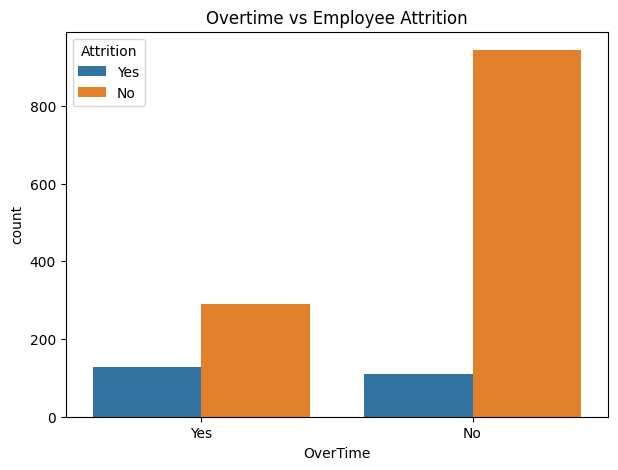

In [68]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='OverTime',
    hue='Attrition'
)

plt.title(
    'Overtime vs Employee Attrition'
)

plt.show()

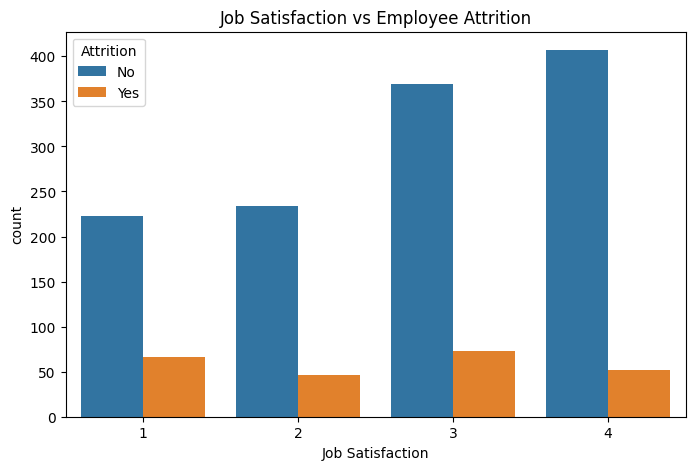

In [69]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='JobSatisfaction',
    hue='Attrition'
)

plt.title(
    'Job Satisfaction vs Employee Attrition'
)

plt.xlabel('Job Satisfaction')

plt.show()

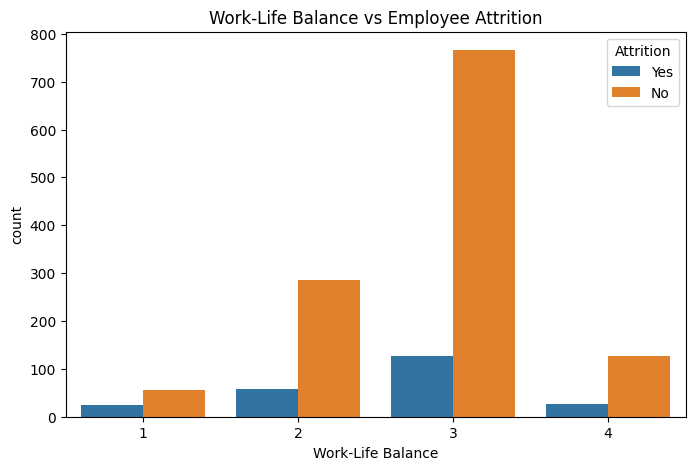

In [70]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='WorkLifeBalance',
    hue='Attrition'
)

plt.title(
    'Work-Life Balance vs Employee Attrition'
)

plt.xlabel('Work-Life Balance')

plt.show()

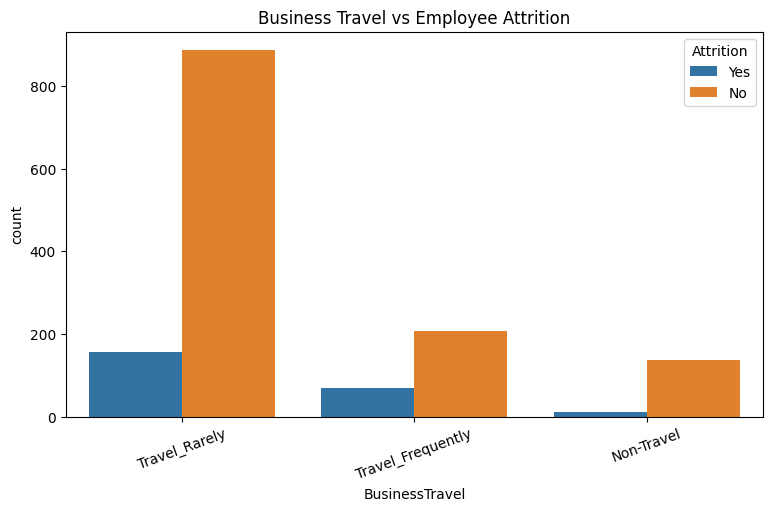

In [71]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x='BusinessTravel',
    hue='Attrition'
)

plt.title(
    'Business Travel vs Employee Attrition'
)

plt.xticks(rotation=20)

plt.show()

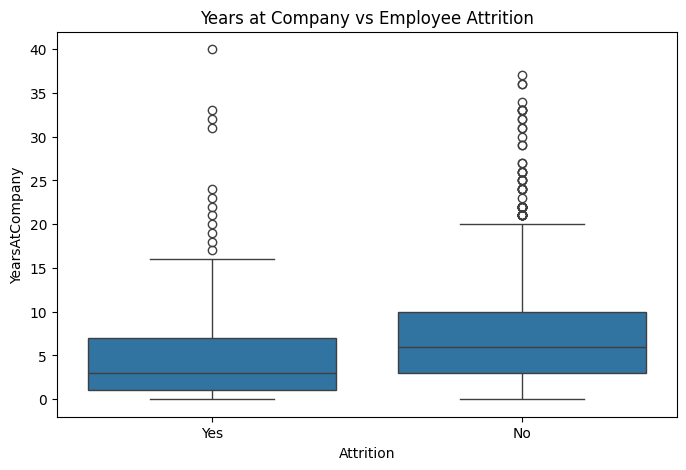

In [72]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Attrition',
    y='YearsAtCompany'
)

plt.title(
    'Years at Company vs Employee Attrition'
)

plt.show()

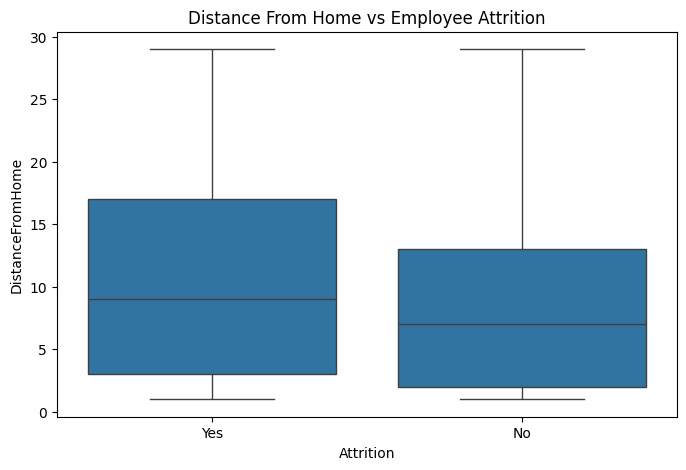

In [73]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Attrition',
    y='DistanceFromHome'
)

plt.title(
    'Distance From Home vs Employee Attrition'
)

plt.show()

In [74]:
numeric_df = df.select_dtypes(
    include=np.number
)

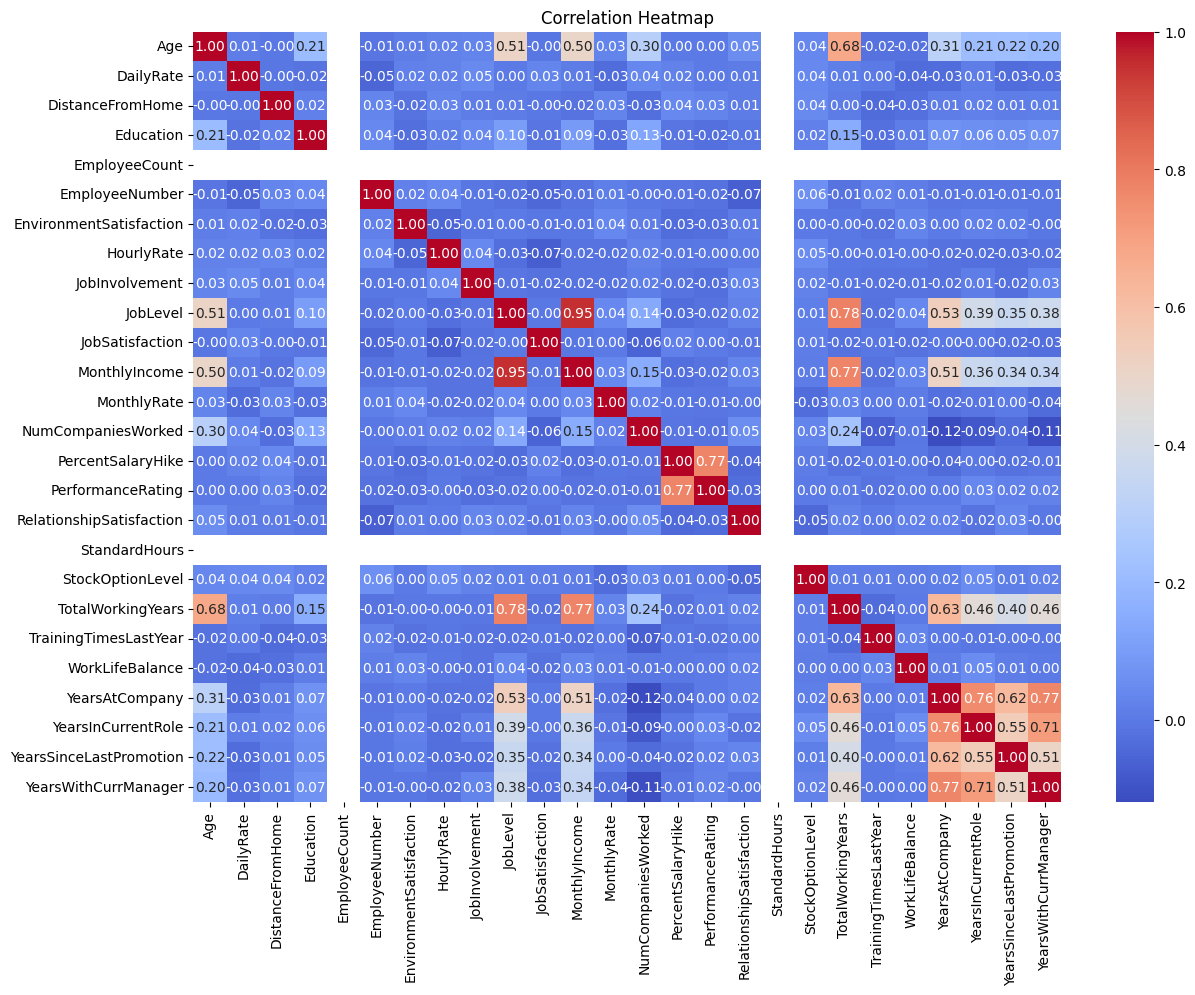

In [75]:
plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title(
    'Correlation Heatmap'
)

plt.show()

In [76]:
ml_df = df.copy()

ml_df['Attrition'] = ml_df[
    'Attrition'
].map({
    'Yes': 1,
    'No': 0
})

In [77]:
columns_to_drop = [
    'EmployeeNumber',
    'EmployeeCount',
    'Over18',
    'StandardHours'
]

ml_df = ml_df.drop(
    columns=columns_to_drop,
    errors='ignore'
)

ml_df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [78]:
columns_to_drop = [
    'EmployeeNumber',
    'EmployeeCount',
    'Over18',
    'StandardHours'
]

ml_df = ml_df.drop(
    columns=columns_to_drop,
    errors='ignore'
)

ml_df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [79]:
y = ml_df['Attrition']
X = ml_df.drop('Attrition', axis=1)

X = pd.get_dummies(
    X,
    drop_first=True
)

X.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,3,61,2,2,2,5130,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,4,92,2,1,3,2090,...,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,4,56,3,1,3,2909,...,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,40,3,1,2,3468,...,True,False,False,False,False,False,False,True,False,False


In [80]:
X = pd.get_dummies(
    X,
    drop_first=True
)

X.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,3,61,2,2,2,5130,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,4,92,2,1,3,2090,...,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,4,56,3,1,3,2909,...,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,40,3,1,2,3468,...,True,False,False,False,False,False,False,True,False,False


In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(
    "Training Data:",
    X_train.shape
)

print(
    "Testing Data:",
    X_test.shape
)

Training Data: (1176, 44)
Testing Data: (294, 44)


In [82]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [83]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [84]:
y_pred_logistic = logistic_model.predict(
    X_test_scaled
)

In [85]:
log_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

log_precision = precision_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

log_recall = recall_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

log_f1 = f1_score(
    y_test,
    y_pred_logistic,
    zero_division=0
)

print("Logistic Regression")
print("----------------------------")
print("Accuracy :", log_accuracy)
print("Precision:", log_precision)
print("Recall   :", log_recall)
print("F1 Score :", log_f1)

Logistic Regression
----------------------------
Accuracy : 0.7517006802721088
Precision: 0.34523809523809523
Recall   : 0.6170212765957447
F1 Score : 0.44274809160305345


In [86]:
print(
    classification_report(
        y_test,
        y_pred_logistic,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.91      0.78      0.84       247
           1       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294



In [87]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [88]:
y_pred_rf = rf_model.predict(
    X_test
)

In [89]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

print("Random Forest")
print("----------------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest
----------------------------
Accuracy : 0.8367346938775511
Precision: 0.4444444444444444
Recall   : 0.0851063829787234
F1 Score : 0.14285714285714285


In [90]:
model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],
    'Accuracy': [
        log_accuracy,
        rf_accuracy
    ],
    'Precision': [
        log_precision,
        rf_precision
    ],
    'Recall': [
        log_recall,
        rf_recall
    ],
    'F1 Score': [
        log_f1,
        rf_f1
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.751701,0.345238,0.617021,0.442748
1,Random Forest,0.836735,0.444444,0.085106,0.142857


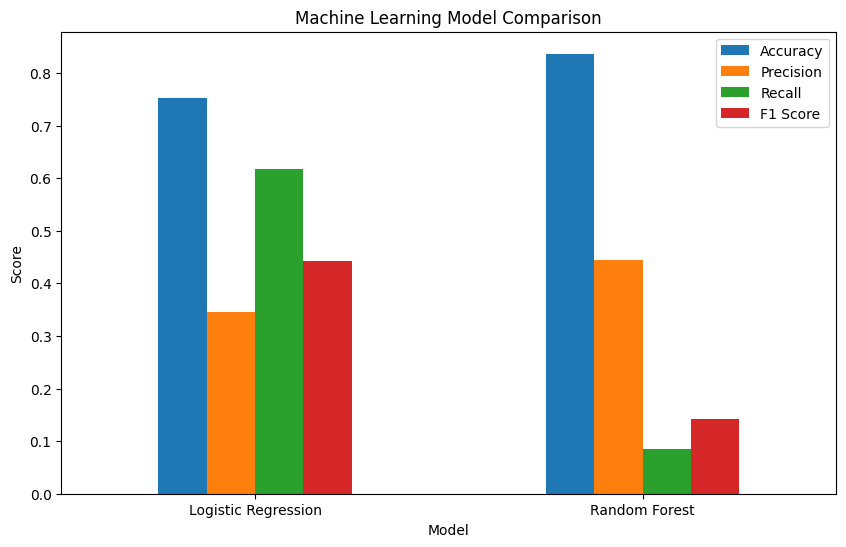

In [91]:
model_comparison.set_index(
    'Model'
)[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score']
].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title(
    'Machine Learning Model Comparison'
)

plt.ylabel('Score')
plt.xticks(rotation=0)

plt.show()

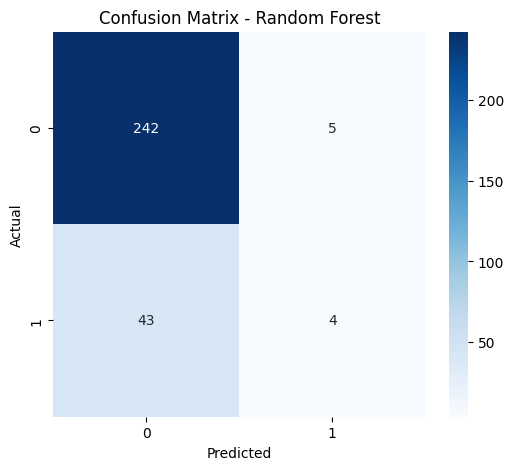

In [92]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Confusion Matrix - Random Forest'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [93]:
rf_probability = rf_model.predict_proba(
    X_test
)[:, 1]

rf_auc = roc_auc_score(
    y_test,
    rf_probability
)

print(
    "Random Forest ROC-AUC:",
    rf_auc
)

Random Forest ROC-AUC: 0.770695150314411


In [94]:
log_probability = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

log_auc = roc_auc_score(
    y_test,
    log_probability
)

print(
    "Logistic Regression ROC-AUC:",
    log_auc
)

Logistic Regression ROC-AUC: 0.7982599707123783


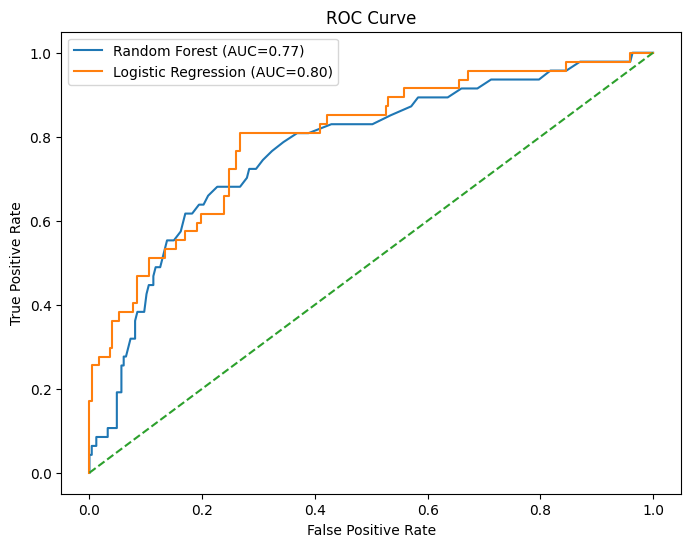

In [95]:
fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    rf_probability
)

fpr_log, tpr_log, _ = roc_curve(
    y_test,
    log_probability
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC={rf_auc:.2f})'
)

plt.plot(
    fpr_log,
    tpr_log,
    label=f'Logistic Regression (AUC={log_auc:.2f})'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend()

plt.show()

In [96]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
9,MonthlyIncome,0.074990
0,Age,0.064265
1,DailyRate,0.054629
16,TotalWorkingYears,0.051717
19,YearsAtCompany,0.050516
10,MonthlyRate,0.046254
5,HourlyRate,0.044628
43,OverTime_Yes,0.043875
22,YearsWithCurrManager,0.042047
2,DistanceFromHome,0.041556


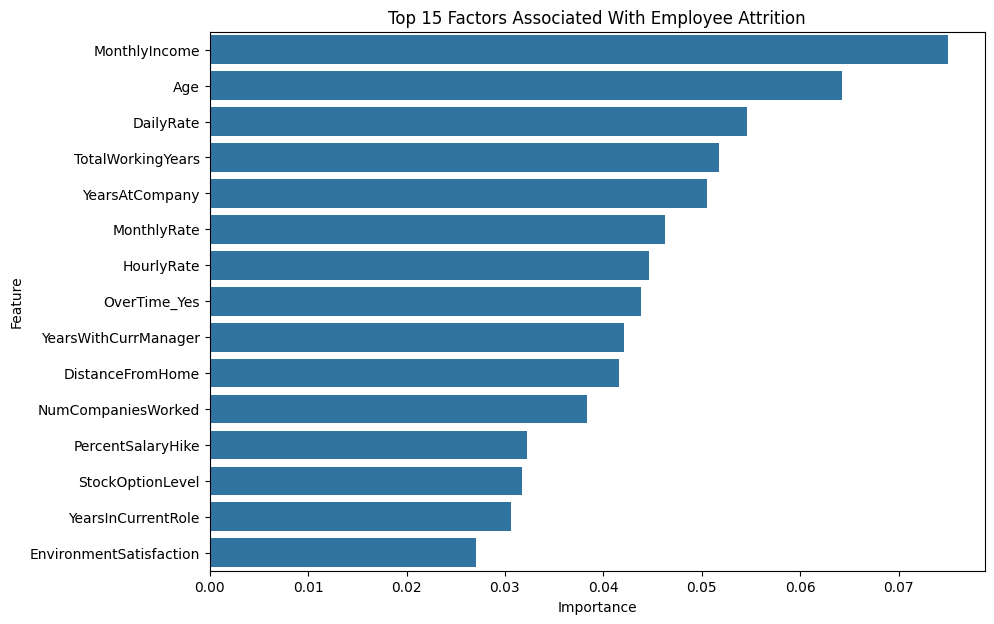

In [97]:
plt.figure(figsize=(10,7))

sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title(
    'Top 15 Factors Associated With Employee Attrition'
)

plt.show()

In [98]:
prediction_probability = (
    rf_model.predict_proba(X_test)[:,1]
)

risk_df = pd.DataFrame({
    'Actual_Attrition': y_test.values,
    'Attrition_Probability': prediction_probability
})

risk_df.head(10)

,Actual_Attrition,Attrition_Probability
0,0,0.620
1,0,0.030
2,0,0.085
3,0,0.010
4,1,0.235
5,0,0.105
6,0,0.030
7,0,0.075
8,0,0.010
9,0,0.400


In [99]:
risk_df['Attrition_Risk_Percentage'] = (
    risk_df['Attrition_Probability'] * 100
)

risk_df.head()

,Actual_Attrition,Attrition_Probability,Attrition_Risk_Percentage
0,0,0.620,62.0
1,0,0.030,3.0
2,0,0.085,8.5
3,0,0.010,1.0
4,1,0.235,23.5


In [100]:
def risk_category(probability):

    if probability >= 0.70:
        return 'High Risk'

    elif probability >= 0.40:
        return 'Medium Risk'

    else:
        return 'Low Risk'

In [101]:
risk_df['Risk_Category'] = (
    risk_df['Attrition_Probability']
    .apply(risk_category)
)

risk_df.head(10)

,Actual_Attrition,Attrition_Probability,Attrition_Risk_Percentage,Risk_Category
0,0,0.620,62.0,Medium Risk
1,0,0.030,3.0,Low Risk
2,0,0.085,8.5,Low Risk
3,0,0.010,1.0,Low Risk
4,1,0.235,23.5,Low Risk
5,0,0.105,10.5,Low Risk
6,0,0.030,3.0,Low Risk
7,0,0.075,7.5,Low Risk
8,0,0.010,1.0,Low Risk
9,0,0.400,40.0,Medium Risk


In [102]:
risk_df['Risk_Category'].value_counts()

,count
Risk_Category,
Low Risk,277
Medium Risk,15
High Risk,2


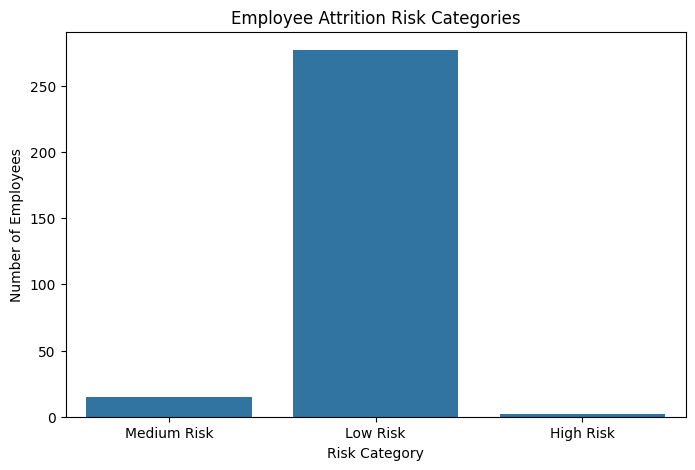

In [103]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=risk_df,
    x='Risk_Category'
)

plt.title(
    'Employee Attrition Risk Categories'
)

plt.xlabel('Risk Category')
plt.ylabel('Number of Employees')

plt.show()

In [104]:
high_risk_employees = risk_df[
    risk_df['Risk_Category'] == 'High Risk'
]

high_risk_employees.head(10)

,Actual_Attrition,Attrition_Probability,Attrition_Risk_Percentage,Risk_Category
92,1,0.735,73.5,High Risk
200,1,0.810,81.0,High Risk


  ***Models:
✓ Logistic Regression
✓ Random Forest***

***Evaluation:
✓ Accuracy
✓ Precision
✓ Recall
✓ F1 Score
✓ ROC-AUC***

***Final***
***Employee Attrition Risk Prediction***